# Assignment 2 - Regression Analysis

Predict the price of an Uber ride from a given pickup point to the agreed drop-off location using Linear, Ridge and Lasso regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Uber dataset
df = pd.read_csv("uber.csv")

# Display first few rows and basic info
print("Dataset Shape:", df.shape)
df.head()
df.info()

Dataset Shape: (200000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


In [2]:
# Drop unnecessary columns (unnamed index column and key)
df = df.drop(columns=['Unnamed: 0', 'key'])

# Handle missing values by dropping them
df = df.dropna()

# Convert pickup_datetime to datetime and extract useful features
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df = df.dropna()  # drop any rows that failed conversion

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df = df.drop(columns=['pickup_datetime'])

# Filter out invalid values (negative or zero fares)
df = df[df['fare_amount'] > 0]
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (199977, 10)


In [3]:
# Identify and remove outliers using the Interquartile Range (IQR) on fare_amount
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR bounds for fare_amount:",
      round(lower_bound, 2), "to", round(upper_bound, 2))

# Filter data within bounds
df_filtered = df[(df['fare_amount'] >= lower_bound) &
                 (df['fare_amount'] <= upper_bound)]
print("Shape after outlier removal:", df_filtered.shape)
print("Outliers removed:", len(df) - len(df_filtered))

IQR bounds for fare_amount: -3.75 to 22.25
Shape after outlier removal: (182822, 10)
Outliers removed: 17155


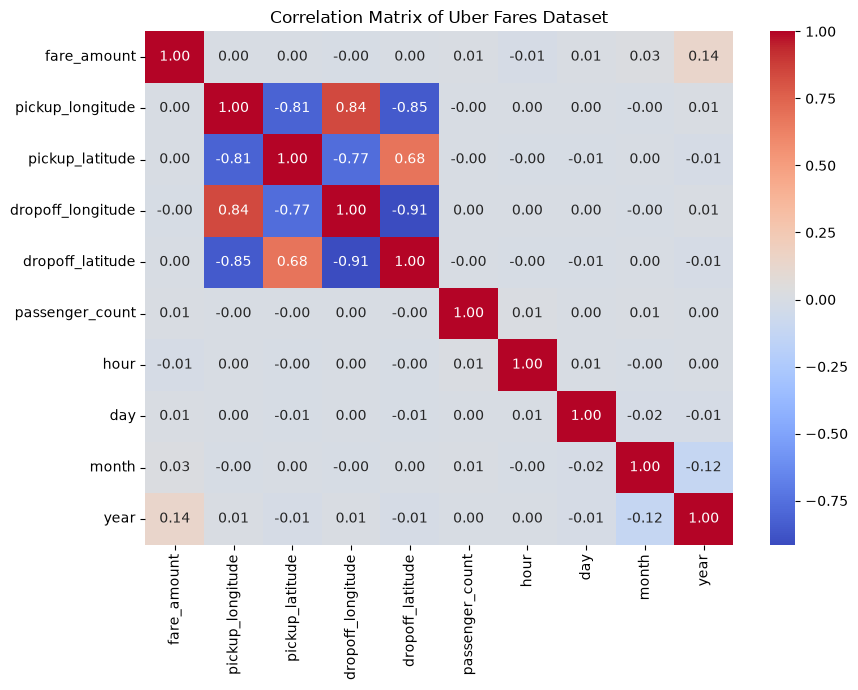


Correlation with fare_amount:
fare_amount          1.0000
year                 0.1354
month                0.0262
passenger_count      0.0126
day                  0.0068
pickup_latitude      0.0026
dropoff_latitude     0.0005
pickup_longitude     0.0004
dropoff_longitude   -0.0023
hour                -0.0133
Name: fare_amount, dtype: float64


In [4]:
# Check the correlation between features
corr_matrix = df_filtered.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Uber Fares Dataset")
plt.tight_layout()
plt.show()

# Correlation of every feature with the target variable
print("\nCorrelation with fare_amount:")
print(corr_matrix['fare_amount'].sort_values(ascending=False).round(4))

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df_filtered.drop(columns=['fare_amount'])
y = df_filtered['fare_amount']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature scaling is important for the regularized models (Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# 3. Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    n = len(y_true)
    p = X_test.shape[1]
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    rmsle = np.log(np.sqrt(mse))
    print(f"--- {model_name} ---")
    print(f"R2 Score:       {r2:.4f}")
    print(f"Adjusted R2:    {adj_r2:.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"MSE:            {mse:.4f}")
    print(f"RMSE:           {rmse:.4f}")
    print(f"RMSLE:          {rmsle:.4f}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")

--- Linear Regression ---
R2 Score:       0.0202
Adjusted R2:    0.0199
MAE:            3.2745
MSE:            17.0814
RMSE:           4.1330
RMSLE:          1.4190

--- Ridge Regression ---
R2 Score:       0.0202
Adjusted R2:    0.0199
MAE:            3.2745
MSE:            17.0814
RMSE:           4.1330
RMSLE:          1.4190

--- Lasso Regression ---
R2 Score:       0.0186
Adjusted R2:    0.0184
MAE:            3.2790
MSE:            17.1087
RMSE:           4.1363
RMSLE:          1.4198



In [8]:
# Compare all three models side by side
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2': [r2_score(y_test, y_pred_lr),
           r2_score(y_test, y_pred_ridge),
           r2_score(y_test, y_pred_lasso)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
             np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
})
results.round(4)

,Model,R2,RMSE
0,Linear Regression,0.0202,4.1330
1,Ridge Regression,0.0202,4.1330
2,Lasso Regression,0.0186,4.1363


In [9]:
# Predict the fare for a new ride: Midtown Manhattan to JFK Airport
new_ride = pd.DataFrame([{
    'pickup_longitude': -73.9857, 'pickup_latitude': 40.7484,
    'dropoff_longitude': -73.7781, 'dropoff_latitude': 40.6413,
    'passenger_count': 1, 'hour': 18, 'day': 15, 'month': 6, 'year': 2015,
}])

new_scaled = scaler.transform(new_ride[X.columns])
print("Predicted fare (Linear):", round(lr.predict(new_scaled)[0], 2))
print("Predicted fare (Ridge): ", round(ridge.predict(new_scaled)[0], 2))
print("Predicted fare (Lasso): ", round(lasso.predict(new_scaled)[0], 2))

Predicted fare (Linear): 9.89
Predicted fare (Ridge):  9.89
Predicted fare (Lasso):  9.76
